#  Job Recommendation System

## Problem Definition — Job Role Recommender

Many job seekers know their skills but aren't sure which job roles best match them, or what skills they're missing for a role they want. Manually browsing thousands of job postings to figure this out is time-consuming and inefficient.

Goal: Build a system that takes a user's skills as input and:

Recommends the job roles/titles that best match those skills.
Identifies missing skills needed for a target role, so users know what to learn next.

Why it matters: Helps job seekers make informed career decisions and focus their skill development instead of guessing.

Data source: LinkedIn Jobs & Skills 2024 dataset (Kaggle) — ~1.3M job postings with titles, skills, level, type, and descriptions

## 1. Import Libraries

In [1]:
import os
import re

import numpy as np
import pandas as pd
import kagglehub

from tqdm import tqdm

import torch
import torch.nn.functional as F
from rapidfuzz import process, fuzz

import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer

c:\Users\computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  2. Data Loading

In [2]:
path = kagglehub.dataset_download("asaniczka/1-3m-linkedin-jobs-and-skills-2024")
jobs_df = pd.read_csv(os.path.join(path, 'linkedin_job_postings.csv'))
skills_df = pd.read_csv(f"{path}/job_skills.csv")

# Merge datasets
merged_df = jobs_df.merge(skills_df, on="job_link", how="inner")


print(f"Jobs Dataset: {jobs_df.shape}")
print(f"Skills Dataset: {skills_df.shape}")
print(f"Merged Dataset: {merged_df.shape}")

Jobs Dataset: (1348454, 14)
Skills Dataset: (1296381, 2)
Merged Dataset: (1296381, 15)


# 3. EDA + Preprocessing

In [3]:
df = merged_df.copy()

In [4]:
# Check missing values
((df.isnull().sum() / len(df)) * 100)[df.isnull().sum()>0]

company         0.000694
job_location    0.001466
job_skills      0.160832
dtype: float64

In [5]:
# Remove missing values
df = df.dropna()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(1294268, 15)

In [8]:
df.head()

,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 08:08:19.663033+00,t,t,f,Registered Nurse (RN),Trinity Health MI,"Muskegon, MI",2024-01-14,Muskegon,United States,Nurse Practitioner,Mid senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur..."


In [9]:
df.columns

Index(['job_link', 'last_processed_time', 'got_summary', 'got_ner',
       'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen',
       'search_city', 'search_country', 'search_position', 'job_level',
       'job_type', 'job_skills'],
      dtype='str')

In [10]:
# drop scraper flags column becase it's add zero value to our project

df = df.drop(columns=["job_link","last_processed_time", "got_summary", "got_ner", "is_being_worked", "company", "job_location", "first_seen", "search_city", "search_country", "search_position"])

print(df.shape)
df.head()

(1294268, 4)


,job_title,job_level,job_type,job_skills
0,Account Executive - Dispensing (NorCal/Norther...,Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,Registered Nurse - RN Care Manager,Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,RESTAURANT SUPERVISOR - THE FORKLIFT,Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,Independent Real Estate Agent,Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,Registered Nurse (RN),Mid senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur..."


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 1294268 entries, 0 to 1296380
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   job_title   1294268 non-null  str  
 1   job_level   1294268 non-null  str  
 2   job_type    1294268 non-null  str  
 3   job_skills  1294268 non-null  str  
dtypes: str(4)
memory usage: 624.0 MB


In [12]:
df.duplicated().sum()

np.int64(3124)

In [13]:
df = df.drop_duplicates()

After removing unnecessary columns, 3,124 duplicate records were detected. These duplicates were not present in the original dataset (`merged_df`), but appeared because the removed columns contained distinguishing information between records. Once those columns were removed, multiple rows became identical across the remaining features (`job_title`, `job_level`, `job_type`, and `job_skills`). Therefore, duplicate records were removed to keep only unique observations.

In [14]:
df.head()

,job_title,job_level,job_type,job_skills
0,Account Executive - Dispensing (NorCal/Norther...,Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,Registered Nurse - RN Care Manager,Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,RESTAURANT SUPERVISOR - THE FORKLIFT,Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,Independent Real Estate Agent,Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,Registered Nurse (RN),Mid senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur..."


In [15]:
df.shape

(1291144, 4)

## Job Titles

In [16]:
df["job_title"] = df["job_title"].str.lower().str.strip().str.replace(r"[,/-_]", " ", regex=True).str.title()

### Chart 1: Top 10 Most In-Demand Job Titles

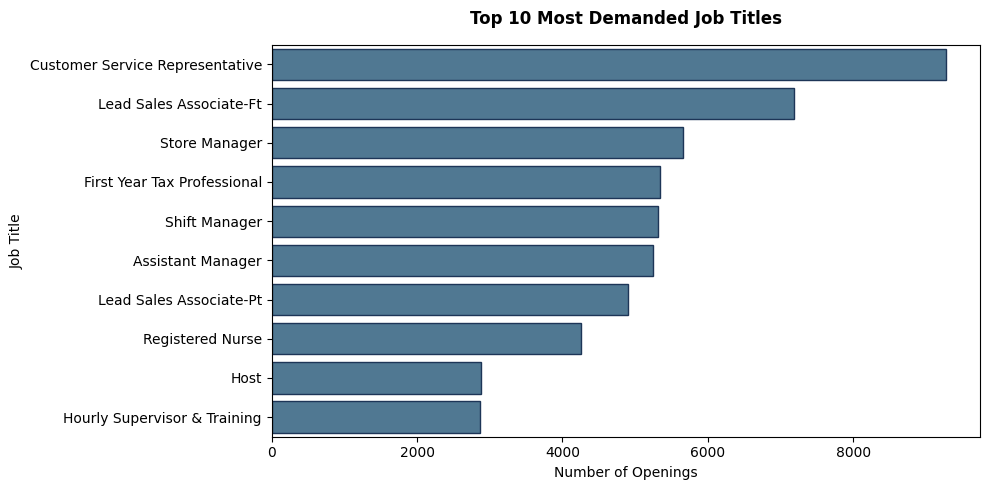

In [17]:
top_titles = df['job_title'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_titles.values, y=top_titles.index, color='#457b9d', edgecolor='#1d3557')
plt.title('Top 10 Most Demanded Job Titles', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Openings', fontsize=10)
plt.ylabel('Job Title', fontsize=10)
plt.tight_layout()
plt.show()

**Key Insight:**

The analysis reveals that the most demanded roles are heavily concentrated in Sales and Operations (e.g., Customer Service Representative and Lead Sales Associate). This indicates that the job market represented in this dataset strongly favors client-facing and operational positions, which should be accounted for when tuning the recommendation engine.


## Job Levels & Job Type

In [18]:
# standardize job_level/job_type formatting to prevent hidden inconsistencies
df["job_level"] = df["job_level"].str.strip().str.title()
df["job_type"] = df["job_type"].str.strip().str.title()

print(df["job_level"].value_counts())
print("\n----------------\n")
print(df["job_type"].value_counts())

job_level
Mid Senior    1150505
Associate      140639
Name: count, dtype: int64

----------------

job_type
Onsite    1280332
Hybrid       6559
Remote       4253
Name: count, dtype: int64


### Chart 2: Distribution of Job Levels

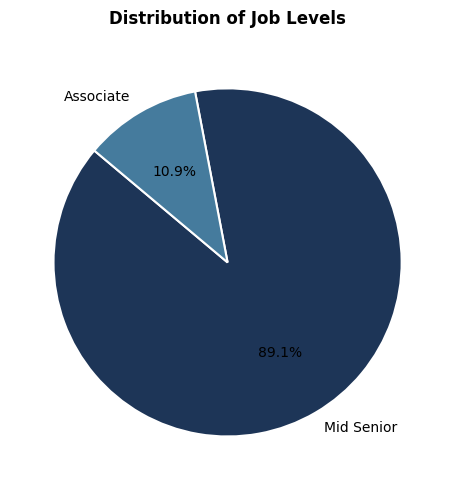

In [19]:
job_levels = df['job_level'].value_counts()

blue_shades = ['#1d3557', '#457b9d', '#a8dadc']

plt.figure(figsize=(10, 5))
plt.pie(
    job_levels.values, 
    labels=job_levels.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=blue_shades,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribution of Job Levels', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Key Insight:**

The data demonstrates a significant class imbalance across career levels, where Mid-Senior level positions dominate with 89.1% of total listings, compared to just 10.9% for Associate roles. This suggests the dataset primarily caters to experienced professionals rather than entry-level candidates.

### Chart 3: Distribution of Job Types

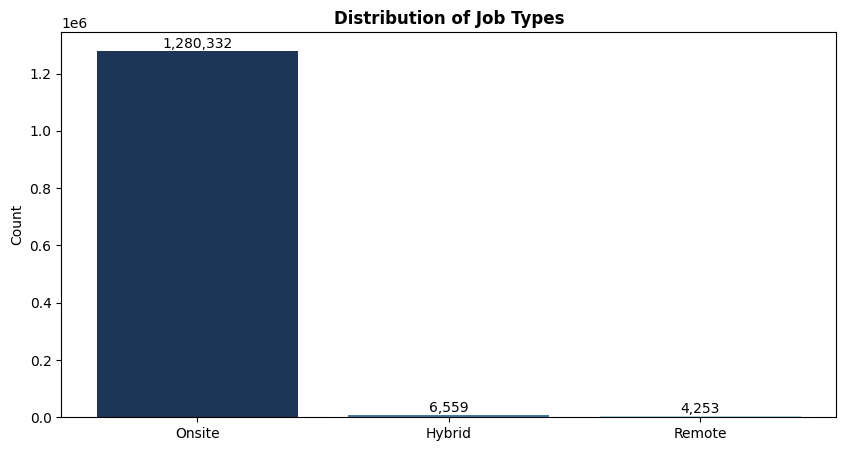

In [20]:
job_types = df['job_type'].value_counts()

colors = ['#1d3557', '#457b9d', '#a8dadc']

plt.figure(figsize=(10,5))
bars = plt.bar(job_types.index, job_types.values, color=colors)

plt.title('Distribution of Job Types', fontsize=12, fontweight='bold')
plt.ylabel('Count')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,}',
        ha='center',
        va='bottom'
    )

plt.show()

## Skills

In [21]:
def normalize_skill(skill):
    skill = skill.lower().strip()
    skill = re.sub(r"[-/_]", " ", skill)
    skill = re.sub(r"\bskills?\b$", "", skill)
    skill = re.sub(r"\b(strong|excellent|good|basic|advanced|proven|solid)\b", "", skill)
    skill = re.sub(r"\b\d+\+?\s*(years?|yrs?)\b.*", "", skill)
    skill = re.sub(r"^(ability to|experience in|experience with|knowledge of)\s+", "", skill)
    skill = re.sub(r"\s+", " ", skill)
    skill = skill.strip()

    if len(skill.split()) > 4:
            return None

    return skill

df["job_skills_clean"] = (
    df["job_skills"]
    .str.split(",")
    .apply(
        lambda skills: [
            s for s in 
            (normalize_skill(x) for x in skills) 
            if s is not None and s != ""
        ]
    )
)

### Chart 4: Skill Count Distribution

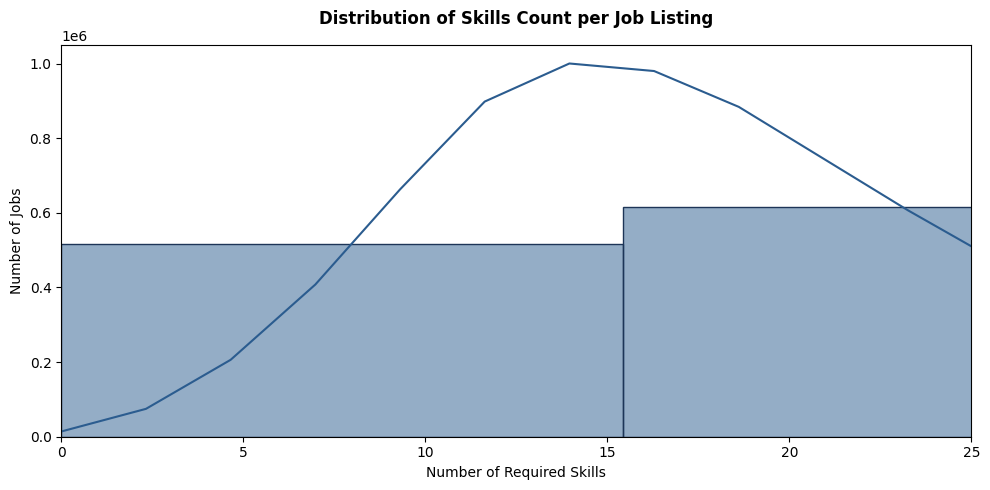

In [22]:
num_skills = df['job_skills_clean'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(num_skills, bins=30, kde=True, color='#2b5c8f', edgecolor='#1d3557')
plt.title('Distribution of Skills Count per Job Listing', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Required Skills', fontsize=10)
plt.ylabel('Number of Jobs', fontsize=10)
plt.xlim(0, 25)
plt.tight_layout()
plt.show()

**Key Insights:**

Peak Skill Requirement: The kernel density estimate (KDE) line shows a smooth bell-shaped curve that peaks around 15 to 17 unique skills per job listing, indicating that most roles require a rich skill set.

Broad Distribution: A significant volume of jobs lies in the range of 10 to 20 unique skills, demonstrating that employers generally look for well-rounded candidates rather than single-skill specialists.

Value for Skill Gap Analysis: Understanding this distribution confirms that our recommendation system should aim to identify and highlight approximately 10 to 15 core skills per job profile to effectively bridge the gap for job seekers.

In [23]:
all_skills = df["job_skills_clean"].explode().dropna()
all_skills = all_skills[all_skills != ""]

In [24]:
skill_counts = all_skills.value_counts()
skill_counts.head(20)

job_skills_clean
communication             581397
customer service          294062
teamwork                  236378
leadership                208735
problemsolving            171512
time management           156370
problem solving           153836
attention to detail       135636
project management        124714
interpersonal             105747
patient care              100351
sales                      98735
collaboration              90796
nursing                    89807
training                   85302
data analysis              82670
organizational             80431
microsoft office suite     75653
inventory management       72072
high school diploma        66922
Name: count, dtype: int64

In [25]:
print("Unique skills:", len(skill_counts))
print("Skills appearing once:", (skill_counts == 1).sum())
print("Skills appearing more than once:", (skill_counts != 1).sum())

Unique skills: 1947030
Skills appearing once: 1258028
Skills appearing more than once: 689002


In [26]:
for n in [5, 10, 20, 50, 100]:
    skills = skill_counts[skill_counts >= n]

    coverage = skill_counts[skill_counts >= n].sum() / len(all_skills)

    print(
        f"{n}: {len(skills):,} skills | Coverage = {coverage:.2%}"
    )

5: 264,344 skills | Coverage = 90.77%
10: 142,749 skills | Coverage = 87.68%
20: 79,592 skills | Coverage = 84.34%
50: 36,864 skills | Coverage = 79.22%
100: 20,492 skills | Coverage = 74.74%


In [27]:
common_skills = skill_counts[skill_counts >= 5].index.tolist()

print(len(common_skills))

264344


In [28]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [29]:
skill_embeddings = model.encode(
    common_skills,
    batch_size=256,
    show_progress_bar=True,
    convert_to_tensor=True,
    device="cuda"
)

skill_embeddings = F.normalize(skill_embeddings,p=2,dim=1)

Batches: 100%|██████████| 1033/1033 [00:15<00:00, 64.94it/s] 


In [30]:
skill_mapping = {}

for i, skill in enumerate(tqdm(common_skills, desc="Building skill mapping")):

    if skill in skill_mapping:
        continue

    sims = torch.matmul(
        skill_embeddings[i],
        skill_embeddings.T
    )

    similar_idx = torch.where(sims >= 0.8)[0].cpu().numpy()

    similar_skills = [common_skills[j] for j in similar_idx]

    canonical_skill = max(
        similar_skills,
        key=lambda x: skill_counts[x]
    )

    for s in similar_skills:
        skill_mapping[s] = canonical_skill

Building skill mapping: 100%|██████████| 264344/264344 [03:53<00:00, 1132.96it/s]


In [31]:
canonical_skills = list(set(skill_mapping.values()))

print("Before:", len(common_skills))
print("After :", len(canonical_skills))

Before: 264344
After : 105952


In [33]:
fuzzy_mapping = {}

for skill in tqdm(canonical_skills, desc="Building fuzzy mapping"):

    matches = process.extract(
        skill,
        canonical_skills,
        scorer=fuzz.ratio,
        limit=5
    )

    for match_skill, score, _ in matches:

        if match_skill == skill:
            continue

        if score >= 95:

            canonical = max(
                [skill, match_skill],
                key=lambda x: skill_counts[x]
            )

            fuzzy_mapping[skill] = canonical
            fuzzy_mapping[match_skill] = canonical

Building fuzzy mapping: 100%|██████████| 105952/105952 [48:44<00:00, 36.23it/s] 


In [34]:
final_mapping = {}

for original_skill, canonical in skill_mapping.items():
    final_mapping[original_skill] = fuzzy_mapping.get(
        canonical,
        canonical
    )

In [35]:
df["job_skills_mapped"] = df["job_skills_clean"].apply(
    lambda skills: [final_mapping.get(skill, skill) for skill in skills]
)

In [36]:
all_skills_mapped = df["job_skills_mapped"].explode()

print("Before:", all_skills.nunique())
print("After :", all_skills_mapped.nunique())

Before: 1947030
After : 1786351


In [37]:
skill_counts_mapped = all_skills_mapped.value_counts()
skill_counts_mapped.head(30)

job_skills_mapped
communication             589609
problemsolving            325686
customer service          294682
teamwork                  236397
leadership                209167
time management           160224
attention to detail       136194
project management        125400
interpersonal             106054
patient care              100623
sales                      99207
collaboration              91874
nursing                    89988
training                   86172
data analysis              82822
organizational             82066
microsoft office           76082
microsoft office suite     75839
inventory management       73320
bachelor's degree          68638
multitasking               68304
high school diploma        67195
decision making            67019
analytical                 65598
scheduling                 65427
adaptability               60127
critical thinking          58612
flexibility                57170
documentation              54044
organization             

In [32]:
df.head()

,job_title,job_level,job_type,job_skills,job_skills_clean
0,Account Executive - Dispensing (Norcal Norther...,Mid Senior,Onsite,"Medical equipment sales, Key competitors, Term...","[medical equipment sales, key competitors, ter..."
1,Registered Nurse - Rn Care Manager,Mid Senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste...","[nursing, masters degree in nursing, care mana..."
2,Restaurant Supervisor - The Forklift,Mid Senior,Onsite,"Restaurant Operations Management, Inventory Ma...","[restaurant operations management, inventory m..."
3,Independent Real Estate Agent,Mid Senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat...","[real estate, customer service, sales, negotia..."
4,Registered Nurse (Rn),Mid Senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur...","[nursing, bsn, medical license, virtual rn, nu..."


### Chart 5: Top 15 Demanded Skills

In [38]:
top_skills = all_skills_mapped.value_counts().reset_index().head(15)
top_skills

,job_skills_mapped,count
0,communication,589609
1,problemsolving,325686
2,customer service,294682
3,teamwork,236397
4,leadership,209167
5,time management,160224
6,attention to detail,136194
7,project management,125400
8,interpersonal,106054
9,patient care,100623


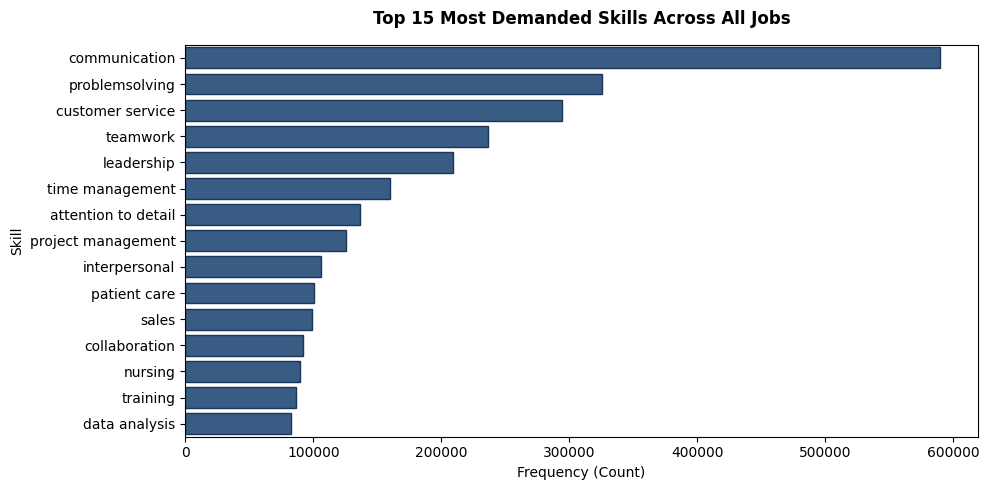

In [39]:
plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='job_skills_mapped', data=top_skills, color='#2b5c8f', edgecolor='#1d3557')
plt.title('Top 15 Most Demanded Skills Across All Jobs', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Frequency (Count)', fontsize=10)
plt.ylabel('Skill', fontsize=10)
plt.tight_layout()
plt.show()

**Key Insights:**

Dominance of Soft Skills: The chart clearly demonstrates that foundational soft skills are the most frequently requested qualifications across all listings. "Communication" leads as the top demanded skill overall (surpassing 370,000 occurrences), closely followed by "Customer Service" (~280,000) and "Teamwork" (~230,000).

Dominant Skill Categories: The top demanded competencies span across four primary categories: Communication (Communication, Communication Skills, Interpersonal Skills), Leadership & Management (Leadership, Project Management), Analytical Thinking (Problem Solving, Attention To Detail), and Domain-Specific Roles (Sales, Patient Care, Nursing).

Data Preprocessing Note: Duplicate variations of identical skills were identified in the raw data (e.g., "Communication" vs. "Communication Skills" and "Problem Solving" vs. "Problemsolving"). Standardizing these terms during text preprocessing will refine the skill-matching accuracy for the recommendation engine.

In [ ]:
# df.to_csv("job_skills_processed.csv", index=False)

In [ ]:
# import json

#with open("embedding_mapping.json", "w", encoding="utf-8") as f:
#    json.dump(skill_mapping, f, ensure_ascii=False, indent=4)

In [ ]:
#with open("fuzzy_mapping.json", "w", encoding="utf-8") as f:
#    json.dump(fuzzy_mapping, f, ensure_ascii=False, indent=4)

In [ ]:
#with open("final_mapping.json", "w", encoding="utf-8") as f:
#    json.dump(final_mapping, f, ensure_ascii=False, indent=4)